# 07 — KNN and Non-parametric Methods

**Covers concept IDs:** F1, F2a, F2b, F3, F4, F5, F6.

## Learning outcomes
1. State the KNN classification rule.
2. Choose the appropriate distance metric (Euclidean vs Hamming) given the data type.
3. Explain the bias–variance trade-off of $K$: why small $K$ overfits and large $K$ underfits.
4. Explain why feature scaling matters for KNN.
5. Explain why KNN boundaries are non-linear, and the computational cost involved.

## 1. The KNN rule (F1)

For a new point $x_{\text{new}}$, find its $K$ nearest training neighbours $x_{i_1},\ldots,x_{i_K}$ under some distance metric, then predict
$$\hat y_{\text{new}} = \arg\max_j \; \frac{1}{K}\sum_{k=1}^K \mathbb 1\{y_{i_k} = j\}.$$

That is, **majority vote** among the $K$ nearest neighbours' labels.

For regression (continuous outcome) replace the majority vote with the **average**: $\hat y_{\text{new}} = \tfrac1K\sum y_{i_k}$.

KNN has **no training phase** — the entire dataset *is* the model. All the work happens at prediction time.

## 2. Distance metrics (F2)

### Euclidean $L_2$
$$d(\mathbf u,\mathbf v) = \sqrt{\sum_j(u_j - v_j)^2}.$$
Use with **continuous** features (after scaling — see §4).

### Hamming
$$d_H(\mathbf u,\mathbf v) = \sum_j \mathbb 1\{u_j \neq v_j\}.$$
Counts the number of coordinates at which two vectors differ. Use with **categorical** features (or their 0/1 dummy encodings).

**Why Hamming for one-hot dummies?** Suppose income has levels {under20k, 20-60k, 60-100k}. After one-hot encoding, two households that differ on exactly one level have Euclidean distance $\sqrt 2$ regardless of *which* level, which is the same answer Hamming gives. With Hamming the metric is unambiguously "how many categorical axes do you disagree on?".

Assignment 4 Q3 used Hamming on the 9 household-demographic dummies and reached test accuracy ≈ 0.50, versus ≈ 0.32 for multinomial logistic.

## 3. Bias–variance in $K$ (F3)

| $K$ | Bias | Variance | Decision boundary |
|---|---|---|---|
| 1 | ~0 (interpolates every training point) | very high | extremely jagged |
| 3-10 | small | moderate | smooth local shape |
| $n/10$ | moderate | small | broad regions |
| $n$ | very high (always predicts the modal class) | 0 | constant |

### Key facts to remember
- **Decreasing $K$ increases overfitting** (Midterm Practice MC 6).
- At $K=1$ with distinct training rows, **training accuracy = 1** (each point is its own nearest neighbour).
- Training accuracy is monotonically non-increasing in $K$; test accuracy is typically U-shaped, minimised at some interior $K^\star$.
- $K$ is the *complexity knob*, playing the same role as $\lambda$ in lasso (but **in the opposite direction**: small $K$ ↔ flexible model, large $K$ ↔ rigid).

## 4. Feature scaling (F4)

Euclidean distance is scale-sensitive: a feature with variance 100 dominates one with variance 1. For KNN on mixed continuous features, always **standardize** (subtract mean, divide by standard deviation) or **min-max normalize**. Otherwise the "neighbours" are determined almost entirely by whichever feature happens to have the largest units, rendering the classifier pathological.

Hamming on 0/1 dummies is already scale-free (every coordinate contributes 0 or 1) — one of the reasons it was a natural choice in Assignment 4.

## 5. Non-linear boundaries & computational cost (F5, F6)

KNN's decision boundary is a **union of Voronoi cells** — arbitrary geometric complexity, free of any parametric assumption. It can capture patterns logistic regression cannot (e.g., two positive clusters separated by negatives).

**Cost.** Every prediction requires scanning all $n$ training points to find the $K$ smallest distances. Prediction is $O(n\,p)$ per query — expensive for large $n$ or high dimensions. Approximate nearest-neighbour structures (KD-trees, ball trees, FAISS) help when $p$ is modest.

**Curse of dimensionality.** In high dimensions, "nearest" neighbours are rarely *close*; all points become roughly equidistant and KNN degrades. Review slide 9 notes: *"KNN... doesn't scale well with $p$."*

## 6. KNN vs logistic regression — exam comparison (F vs C)

| | Linear / logistic | KNN |
|---|---|---|
| Parametric? | Yes ($p+1$ parameters) | No |
| Training cost | moderate (optimization) | none (store data) |
| Prediction cost | $O(p)$ | $O(np)$ |
| Boundary shape | linear in $\beta$ | non-linear, local |
| Feature scaling? | optional (interpretation) | required for Euclidean |
| Interpretability | high (coefficients) | low |
| Small-sample behaviour | stable | noisy |
| Large-$p$ behaviour | often still usable (with lasso) | curse of dimensionality |

## 7. Hand KNN on a 2D toy example

Training points:

| $i$ | $x_1$ | $x_2$ | $y$ |
|---|---|---|---|
| 1 | 0 | 0 | A |
| 2 | 0 | 1 | A |
| 3 | 1 | 0 | B |
| 4 | 2 | 2 | B |
| 5 | 3 | 1 | B |

Query $x_{\text{new}} = (1, 1)$.

Euclidean distances:
- $d_1 = \sqrt{2} \approx 1.414$
- $d_2 = 1$
- $d_3 = 1$
- $d_4 = \sqrt 2 \approx 1.414$
- $d_5 = 2$

- **$K=1$:** break ties to e.g. row 2 (or row 3). Prediction depends on tie-break: A or B.
- **$K=3$:** neighbours = {2, 3, 1} (or {2, 3, 4} — both at $\sqrt 2$). With {2,3,1}: labels A, B, A → **A**. With {2,3,4}: A, B, B → **B**.
- **$K=5$:** all five points → labels A, A, B, B, B → **B**.

**Moral.** Ties and the choice of $K$ matter; small $K$ is noisy.

## 8. Code demo — KNN decision boundary vs $K$

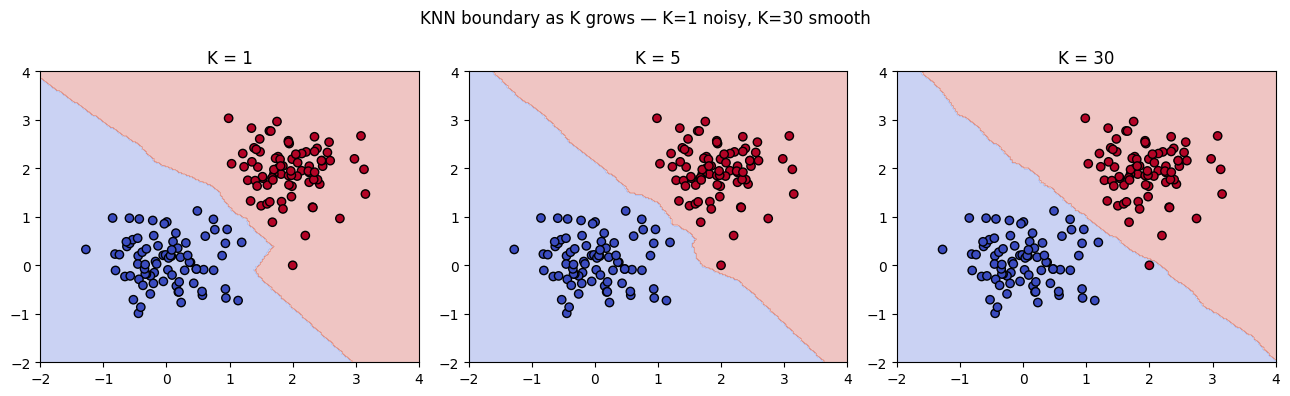

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

np.random.seed(0)
# two-cluster classification toy
n = 80
X1 = np.random.normal([0,0], 0.5, size=(n,2))
X2 = np.random.normal([2,2], 0.5, size=(n,2))
X = np.vstack([X1, X2])
y = np.array([0]*n + [1]*n)
# add some noise
X[5] = [2, 0]
y[5] = 1

xx, yy = np.meshgrid(np.linspace(-2, 4, 200), np.linspace(-2, 4, 200))
grid = np.column_stack([xx.ravel(), yy.ravel()])

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, K in zip(axes, [1, 5, 30]):
    knn = KNeighborsClassifier(n_neighbors=K).fit(X, y)
    zz = knn.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k')
    ax.set_title(f'K = {K}')
plt.suptitle('KNN boundary as K grows — K=1 noisy, K=30 smooth')
plt.tight_layout(); plt.show()

## 9. Practice problems

### 9.1 MC style
> Which method is non-parametric? (A) logistic (B) linear (C) KNN (D) ridge.

**Answer.** **(C) KNN** — no parametric form, no finite parameter vector.

### 9.2 MC style
> In KNN, decreasing $K$ generally: (A) increases bias (B) decreases variance (C) increases overfitting (D) smooths the decision boundary.

**Answer.** **(C) increases overfitting.** Smaller $K$ ⇒ more flexible, more variance, jagged boundaries.

### 9.3 Concept
> Why can KNN produce non-linear decision boundaries?

**Answer.** KNN classifies each new point by the labels of its $K$ nearest *training* neighbours, with no global parametric form. The induced boundary is a union of Voronoi cells, which can take arbitrary shape — the method places no "linear-in-$\beta$" constraint on the boundary.

### 9.4 Concept
> Why does feature scaling matter?

**Answer.** Euclidean distance is scale-sensitive. If one feature has variance 100 and another 1, the first dominates the distance, so KNN effectively ignores the second. Standardizing all features to unit variance gives each coordinate equal influence on neighbourhood selection.

### 9.5 Short answer — AI certificate scenario (Midterm Practice 1.2.2)
> Logistic regression vs. $K=5$ KNN on the same two features. Which likely has **higher training accuracy**?

**Answer.** $K=5$ KNN. It uses a flexible, local decision rule that can carve arbitrary non-linear regions around each training point; with enough data points it will trace closely around the training labels. Logistic regression is constrained to a single linear boundary in the two-feature plane, so it necessarily misclassifies any training observations that don't conform to a linear separation. That said, KNN's *test* accuracy can be worse if the boundary it overfits doesn't generalize.

### 9.6 Training accuracy at K=1
> With unique training feature vectors, what is the training accuracy of $K=1$ KNN?

**Answer.** 100%. Each training point's nearest neighbour is itself (distance 0), so the model always predicts its own label. This is the clearest signature of KNN's tendency to overfit at $K=1$.